<a href="https://colab.research.google.com/github/srivijay-1512/Python-data-analysis-project/blob/main/VijayFinalproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=====SALES RECORD=====
   order_id customer_id  gender  age product_category product_name  quantity  \
0   ORD0001    CUST9376  Female   43             Home         Lamp         1   
1   ORD0002    CUST3289    Male   57             Toys     Lego Set         5   
2   ORD0003    CUST6409  Female   53         Clothing       Jacket         1   
3   ORD0004    CUST8815  Female   51           Beauty      Perfume         2   
4   ORD0005    CUST1018  Female   39      Electronics   Smartphone         4   
..      ...         ...     ...  ...              ...          ...       ...   
95  ORD0096    CUST3955    Male   49             Home     Curtains         4   
96  ORD0097    CUST5677    Male   36           Beauty   Face Cream         4   
97  ORD0098    CUST1271    Male   57             Home     Curtains         3   
98  ORD0099    CUST1105  Female   21         Clothing        Jeans         3   
99  ORD0100    CUST9956  Female   32      Electronics   Headphones         2   

      price  ord

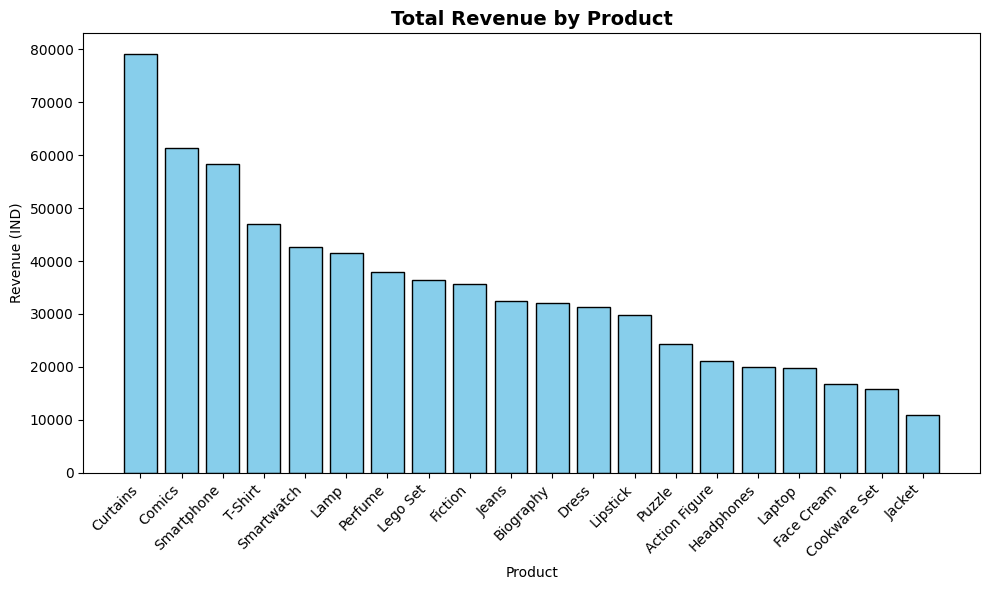

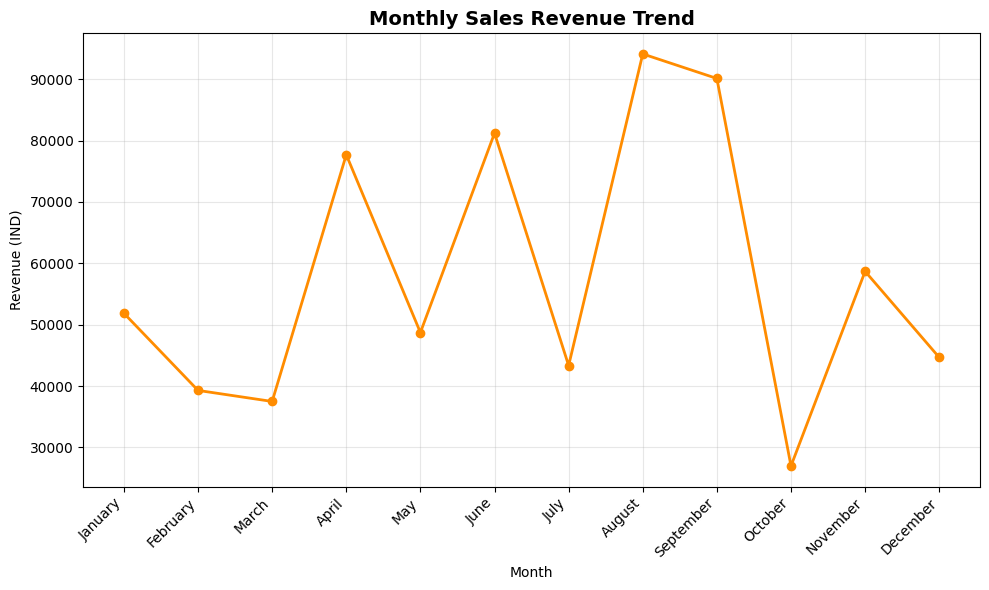

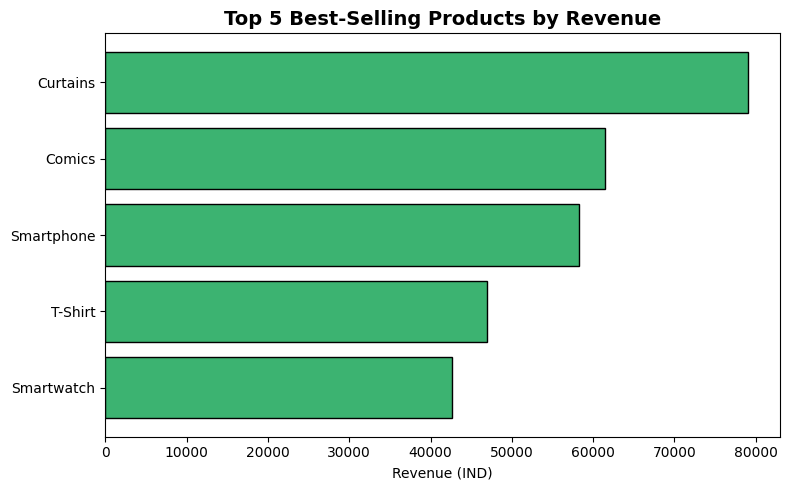

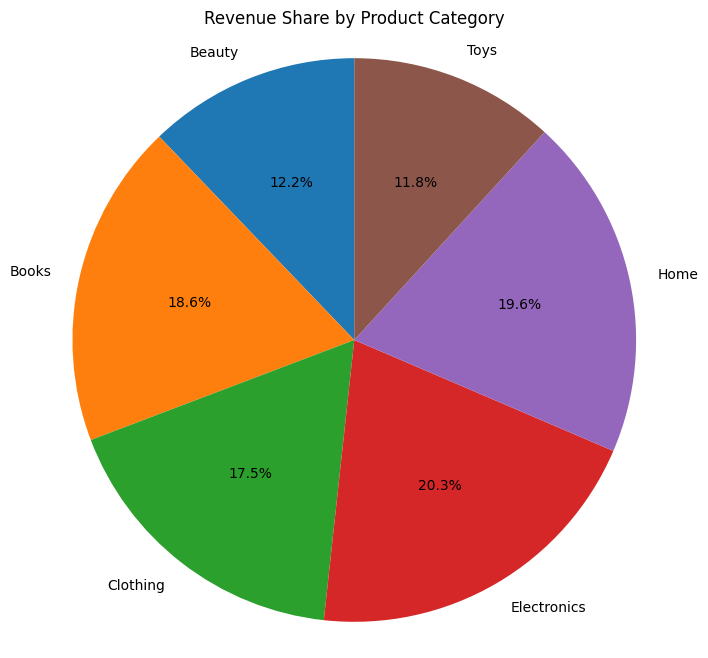

===== SUMMARY ===
Best-selling product: Curtains (₹79,023.10)

Best-performing month: August (₹94,121.76)

Total revenue across all sales: ₹694,219.87

Total orders analyzed: 100



In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from google.colab import files
uploaded = files.upload()

data = pd.read_csv('ecom_sale.csv')
df = pd.DataFrame(data)
print("=====SALES RECORD=====")
print(df)

print("======SALES INFO=====")
print(df.info())

print("Shape of dataset:", df.shape)
df.head()



print("Missing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nData types:\n", df.dtypes)


numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

text_cols = df.select_dtypes(include='object').columns
for col in text_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna('Unknown')


before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Removed {before - after} duplicate rows")


df['order_date'] = pd.to_datetime(df['order_date'], format='%Y-%m-%d', errors='coerce')


print("NaNs in 'order_date' after conversion:", df['order_date'].isnull().sum())
df = df.dropna(subset=['order_date'])


df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce')
df['price'] = pd.to_numeric(df['price'], errors='coerce')

print("NaNs in 'quantity' after conversion:", df['quantity'].isnull().sum())
print("NaNs in 'price' after conversion:", df['price'].isnull().sum())
df = df.dropna(subset=['quantity', 'price'])


print("Cleaned dataset shape:", df.shape)


print("\nUnique values in 'quantity':\n", df['quantity'].unique())




df['Revenue'] = df['quantity'] * df['price']
df['Month'] = df['order_date'].dt.month_name()
df['Month_Num'] = df['order_date'].dt.month   # used for correct chronological sorting

print(df[['product_name', 'quantity', 'price', 'Revenue', 'Month']].head())



revenue_by_product = (
    df.groupby('product_name')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

print("Top 5 products by revenue:\n", revenue_by_product.head())

print("\nTotal revenue: ₹{:,.2f}".format(np.sum(revenue_by_product.values)))
print("Average revenue per product: ₹{:,.2f}".format(np.mean(revenue_by_product.values)))



month_order = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']

revenue_by_month = (
    df.groupby('Month')['Revenue']
    .sum()
    .reindex(month_order)
    .fillna(0)
)

print("Monthly revenue:\n", revenue_by_month)



plt.figure(figsize=(10, 6))
plt.bar(revenue_by_product.index, revenue_by_product.values, color='skyblue', edgecolor='black')
plt.title('Total Revenue by Product', fontsize=14, fontweight='bold')
plt.xlabel('Product')
plt.ylabel('Revenue (IND)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
plt.plot(revenue_by_month.index, revenue_by_month.values,
         marker='o', linewidth=2, color='darkorange')
plt.title('Monthly Sales Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (IND)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

top5 = revenue_by_product.head(5)

plt.figure(figsize=(8, 5))
plt.barh(top5.index[::-1], top5.values[::-1], color='mediumseagreen', edgecolor='black')
plt.title('Top 5 Best-Selling Products by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Revenue (IND)')
plt.tight_layout()
plt.show()



best_product = revenue_by_product.idxmax()
best_month = revenue_by_month.idxmax()



category_revenue = df.groupby("product_category")["Revenue"].sum()

plt.figure(figsize=(8, 8))
plt.pie(
    category_revenue,
    labels=category_revenue.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Revenue Share by Product Category")
plt.axis("equal")
plt.show()

print("===== SUMMARY ===")
print(f"Best-selling product: {best_product} (₹{revenue_by_product.max():,.2f})\n")
print(f"Best-performing month: {best_month} (₹{revenue_by_month.max():,.2f})\n")
print(f"Total revenue across all sales: ₹{df['Revenue'].sum():,.2f}\n")
print(f"Total orders analyzed: {len(df)}\n")